In [1]:
import sys

if 'workhorse' not in sys.executable.split('/'):
    origin = 'workspace/'
    sys.path.append('/media/')
else:
    origin = 'data/Aldhani/eoagritwin/'
    sys.path.append('/home/potzschf/repos/')

from helperToolz.polygons_to_labels import *
from helperToolz.helpsters import *
import xarray as xr
import rioxarray
from helperToolz.feevos.rocksdbutils_copy import *
from math import ceil as mceil

ModuleNotFoundError: No module named 'rocksdb'

In [2]:
# load a rocksdb dataset
fine_set = RocksDBDataset('/workspace/fields/output/rocks_db/Fine_tuner.db/train.db', transform=None)

In [ ]:
ai4_set = RocksDBDataset('/workspace/fields/output/rocks_db/AI4_RGB_exclude_True.db/train.db', transform=None)

In [ ]:
ai4_data = []
ai4_labels = []
for i in range(len(ai4_set)):
    ai4_data.append(np.unique(ai4_set[i][0]))
    ai4_labels.append(np.unique(ai4_set[i][1]))

In [3]:
fine_data = []
fine_labels = []
for i in range(len(fine_set)):
    fine_data.append(np.unique(fine_set[i][0], return_counts=True))
    fine_labels.append(np.unique(fine_set[i][1]))

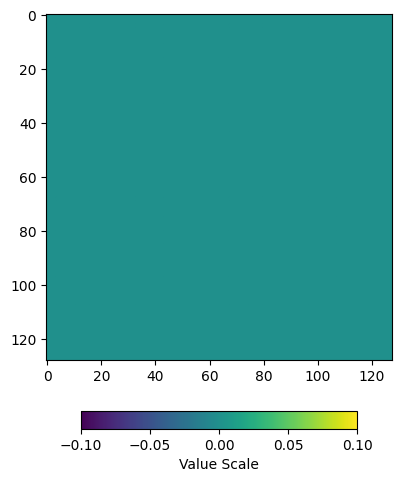

In [20]:
plotter(fine_set[0][1][3,:,:])

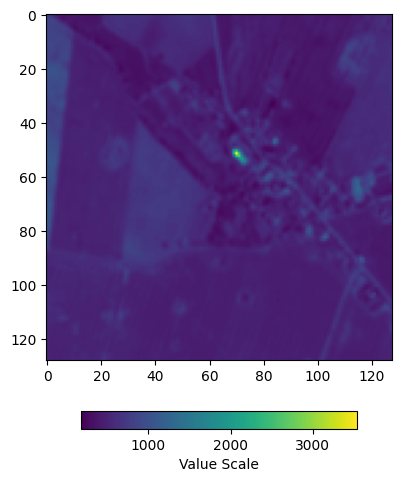

In [16]:
plotter(fine_set[0][0][0,0,:,:])

In [25]:
no_count = [f for fd in fine_data for f in fd[0]]


KeyboardInterrupt: 

In [ ]:
for count, i in enumerate(fine_data):
    if np.isnan(i[0]).any():
        print(count)

In [ ]:
ai4_data_uni = np.unique([f for fd in ai4_data for f in fd])
ai4_labels_uni = np.unique([f for fd in ai4_labels for f in fd])

In [2]:
# check nc files
variables2use=['B2','B3','B4','B8']
nc_files = getFilelist(f'/{origin}fields/Fine_tune/', '.nc', deep=True)

In [6]:
for i in range(len(nc_files)):
    nc_file = xr.open_dataset(nc_files[i])
    image = np.concatenate([nc_file[var].values[None] for var in variables2use],0)
    if len(np.unique(image)) == 1:
        print(i)
        print(nc_files[i])
        print(np.unique(image))

In [ ]:
label_files = getFilelist(f'/{origin}fields/Fine_tune/', '.tif', deep=True)
for i in range(len(label_files)):
    arr = stackReader(label_files[i])
    print(np.unique(arr))

In [3]:
# mock the normalisation when pressing into rocks
normi = AI4BNormal_S2()

for i in range(len(nc_files)):
    nc_file = xr.open_dataset(nc_files[i])
    image = np.concatenate([nc_file[var].values[None] for var in variables2use],0)
    #plotter(image)
    if np.isnan(np.unique(normi(image))).any() == True:
        print(f'{i}: {nc_files[i]}')

In [54]:
i = 995
nc_file = xr.open_dataset(nc_files[i])
image = np.concatenate([nc_file[var].values[None] for var in variables2use],0)
norm_image = normi(image)
image[np.where(np.isnan(norm_image) == True)]

array([nan], dtype=float32)

In [55]:
np.where(np.isnan(norm_image) == True)

(array([3]), array([0]), array([57]), array([209]))

In [57]:
13824+57-1

13880

In [56]:
18688+209-1

18896

In [60]:
nc_files[i]

'/workspace/fields/Fine_tune/img/MV/2023/MV_2023_rowstart_13824_colstart_18688.nc'

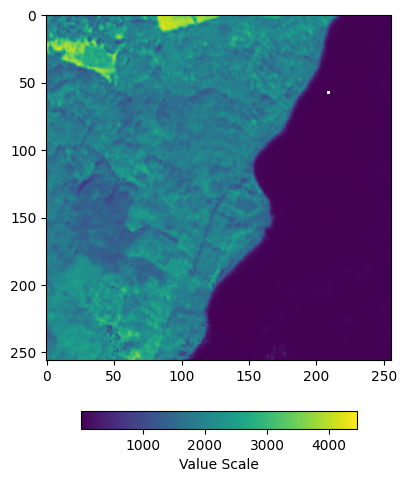

In [58]:
plotter(image[3,0,:,:])

In [17]:
arr = stackReader('/workspace/fields/Auxiliary/vrt/MV/2023/Force_X_from_63_to_71_Y_from_35_to_41/Force_X_from_63_to_71_Y_from_35_to_41_Cube.vrt')

In [83]:
arr[13881,18897,:]

array([103, 148, 202, 248, 403, 229,  93, 149, 235, 288, 528, 264,  22,
        78, 148, 166, 255, 152,   0,  74, 212, 193, 189, 156], dtype=int16)

In [42]:
arr[9025,4752,:]

array([345, 363, 379, 385, 383, 365, 465, 498, 525, 530, 515, 496, 108,
       195, 240, 270, 263, 184,   0,  77, 122, 144, 175, 105], dtype=int16)

In [51]:
IACS_path = f'/{origin}fields/IACS/1_Polygons/'
temp_folder = f'/{origin}fields/IACS/temp_trash/'
out_folder = f'/{origin}fields/Fine_tune/'
FORCE_folder = f'/{origin}force/output/'
aux_vrt_path = f'/{origin}fields/Auxiliary/vrt/'

# set state and year
state_folder='MV'
year = 2023

In [52]:
force_arr = loadVRTintoNumpyAI4(f"{aux_vrt_path}{state_folder}/{year}/{dirfinder(f'{aux_vrt_path}{state_folder}/{year}/')[0]}",
                                    applyNormalizer=False)

In [82]:
np.where(force_arr[:,:,(13824+57),(18688+209)] == 0)

(array([3]), array([0]))

In [4]:
t_exts = [i/100 for i in range(10,95,5)] 
t_bounds = [i/100 for i in range(10,95,5)]

i = 0

for text in t_exts:
    for tboun in t_bounds:
        i += 1
print(i)

289


In [5]:
2312/289

8.0